In [1]:
import os
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
print(os.getcwd())
os.chdir("../")
os.getcwd()

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\notebooks


'c:\\Users\\leoco\\Documents\\cours\\M2_MOSEF\\ML_theory\\land_value_prediction'

In [3]:
from src.land_value_prediction.feature_selection import (compute_shap_results, 
                                                         compute_shap_summary, 
                                                         plot_strong_correlations)

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_train = pd.read_parquet(r"data\processed\train_test_out_sample_cleaned\idf_vf_train_cleaned.parquet")

In [5]:
cols_to_remove = ['prix_m2', 'ecart_prix_median_pct', 'is_maison', 'nord_paris', 'est_paris', "code_departement"]
df_code_departement = df_train[['code_departement']].copy()

X = df_train.drop(columns=cols_to_remove)
y = df_train['prix_m2']

print(f"Dataset: {X.shape[0]:,} échantillons, {X.shape[1]} features")
print(f"Target (prix_m2): min={y.min():.0f}, max={y.max():.0f}, médiane={y.median():.0f}")

Dataset: 507,388 échantillons, 102 features
Target (prix_m2): min=1500, max=15000, médiane=4762


In [6]:
# Créer 10 bins pour stratification
n_bins = 10
binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
y_binned = binner.fit_transform(y.values.reshape(-1, 1)).ravel().astype(int)

# Vérifier la distribution
print(f"Target divisée en {n_bins} bins (quantiles)")
bin_counts = pd.Series(y_binned).value_counts().sort_index()
print("Distribution des bins:")
for bin_idx, count in bin_counts.items():
    print(f"   Bin {int(bin_idx)}: {count:>6} échantillons ({count/len(y)*100:>5.1f}%)")

Target divisée en 10 bins (quantiles)
Distribution des bins:
   Bin 0:  50523 échantillons ( 10.0%)
   Bin 1:  50106 échantillons (  9.9%)
   Bin 2:  50595 échantillons ( 10.0%)
   Bin 3:  50468 échantillons (  9.9%)
   Bin 4:  50649 échantillons ( 10.0%)
   Bin 5:  50392 échantillons (  9.9%)
   Bin 6:  51252 échantillons ( 10.1%)
   Bin 7:  51548 échantillons ( 10.2%)
   Bin 8:  51036 échantillons ( 10.1%)
   Bin 9:  50819 échantillons ( 10.0%)


c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [7]:
shap_results = compute_shap_results(X, y, y_binned, binner=binner, n_bins=n_bins, n_folds=5)

 FOLD 1/5
   Train: 405910 échantillons
   Val:   101478 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=7999, max=15000
   MAE train: 1003.66
   MAE val:   1005.58
 FOLD 2/5
   Train: 405910 échantillons
   Val:   101478 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=8000, max=15000
   MAE train: 1001.82
   MAE val:   1011.12
 FOLD 3/5
   Train: 405910 échantillons
   Val:   101478 échantillons
   Target train: min=1500, Q25=3306, med=4762, Q75=8000, max=15000
   MAE train: 1001.57
   MAE val:   1010.87
 FOLD 4/5
   Train: 405911 échantillons
   Val:   101477 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=7998, max=15000
   MAE train: 1003.17
   MAE val:   1005.63
 FOLD 5/5
   Train: 405911 échantillons
   Val:   101477 échantillons
   Target train: min=1500, Q25=3308, med=4762, Q75=7997, max=15000
   MAE train: 1002.17
   MAE val:   1013.12


Pas d'overfit, la sélection est robuste. Et ça donne également un benchmark avec une MAE d'environ 1000. 

In [8]:
results_df = compute_shap_summary(shap_results, X)
results_df

,feature,shap_mean,shap_norm
3,prix_m2_median_maisons_voisines,1265.514630,100.000000
92,ratio_terrain_bati,355.956316,28.125961
100,surface_x_type,290.977186,22.991257
25,commune_education_score_2013_commune,237.237852,18.744731
87,nb_transport_autre_2000m,201.601127,15.928688
...,...,...,...
62,nb_transport_autre_500m,0.174005,0.011752
52,nb_sante_500m,0.163365,0.010911
50,nb_restauration_500m,0.140768,0.009126
48,nb_commerce_500m,0.087294,0.004900


On ne garde que les variables pour lesquelles la valeur de shapley est supérieure à 1% de la valeur de Shapley maximum. 

In [9]:
selected_features = results_df[results_df["shap_norm"] > 1]["feature"].tolist()
print(f"On ne garde que {len(selected_features)} features avec un SHAP normalisé > 1")
print(f"Ce sont les features suivantes: {selected_features}")

On ne garde que 32 features avec un SHAP normalisé > 1
Ce sont les features suivantes: ['prix_m2_median_maisons_voisines', 'ratio_terrain_bati', 'surface_x_type', 'commune_education_score_2013_commune', 'nb_transport_autre_2000m', 'densite_rel_2000m', 'is_appartement', 'nombre_lots', 'commune_part_commerce_tourisme', 'distance_paris', 'commune_densite_residences_principales_2020', 'nombre_pieces_principales', 'commune_revenu_median_2020', 'surface_terrain', 'nb_jours_depuis_janvier_2021', 'commune_ratio_residences_secondaires_population', 'commune_etablissements_1_salarie_2021', 'surface_par_piece', 'densite_lots', 'Taux_moyen_credit_immo_lag3t', 'commune_idh2_2013_commune', 'nb_total_2000m', 'dist_transport_lourd', 'prix_median_x_distance', 'Taux_moyen_credit_immo_lag1t', 'commune_taux_proprietaires', 'nb_loisirs_2000m', 'Evolution_PIB_volume_en_%_base2020_lag4t', 'nb_services_2000m', 'commune_taux_residences_secondaires', 'commune_densite_pop', 'nb_education_2000m']


In [10]:
df_train_with_selected_features = df_train[selected_features + ['prix_m2']]
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,nb_transport_autre_2000m,densite_rel_2000m,is_appartement,nombre_lots,commune_part_commerce_tourisme,distance_paris,...,prix_median_x_distance,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,nb_loisirs_2000m,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,commune_taux_residences_secondaires,commune_densite_pop,nb_education_2000m,prix_m2
0,9782.608398,0.000000,160,0.902589,27,1.355828,1,1,0.848215,0.042164,...,412.474609,0.0373,0.325563,290,0.193834,17,0.097947,27060.376953,122,7750.000000
1,5606.589355,0.000000,52,0.451268,4,0.241548,1,1,0.643595,0.073735,...,413.401489,0.0399,0.282208,235,0.900489,8,0.020091,12059.680664,56,4500.000000
2,3152.272705,0.000000,101,0.636588,2,-1.289530,0,1,0.600000,0.288966,...,910.898926,0.0329,0.811383,33,0.506923,2,0.022015,607.500000,2,2623.762451
3,10938.690430,0.000000,36,0.824937,31,2.088961,1,1,0.852084,0.021931,...,239.891357,0.0106,0.370956,307,15.361810,17,0.095681,31270.587891,185,12111.111328
4,5555.555664,1.843374,83,0.650801,1,0.010234,0,0,0.773960,0.127345,...,707.473755,0.0106,0.483656,228,15.361810,3,0.021328,8318.695312,33,8192.771484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,3135.065430,0.000000,204,0.549603,0,0.113545,1,2,0.724356,0.112861,...,353.825867,0.0284,0.344608,248,0.440900,10,0.008835,8136.649414,62,2774.509766
507384,7936.507812,0.000000,92,0.702535,4,0.693273,1,2,0.761356,0.083150,...,659.923889,0.0113,0.422412,226,-12.214629,14,0.034864,17674.480469,78,7282.608887
507385,1771.571777,0.000000,76,0.234840,1,-0.880271,0,1,0.664062,0.462352,...,819.089783,0.0113,0.423093,33,-12.214629,3,0.007286,2734.945801,5,2763.157959
507386,5403.879395,0.000000,160,0.470862,4,1.436748,1,1,0.739228,0.138005,...,745.762024,0.0105,0.283137,331,-0.105712,15,0.022789,7801.886719,88,5000.000000


On doit maintenant procéder à une nouvelle analyse des corrélations présentes dans le dataframe :

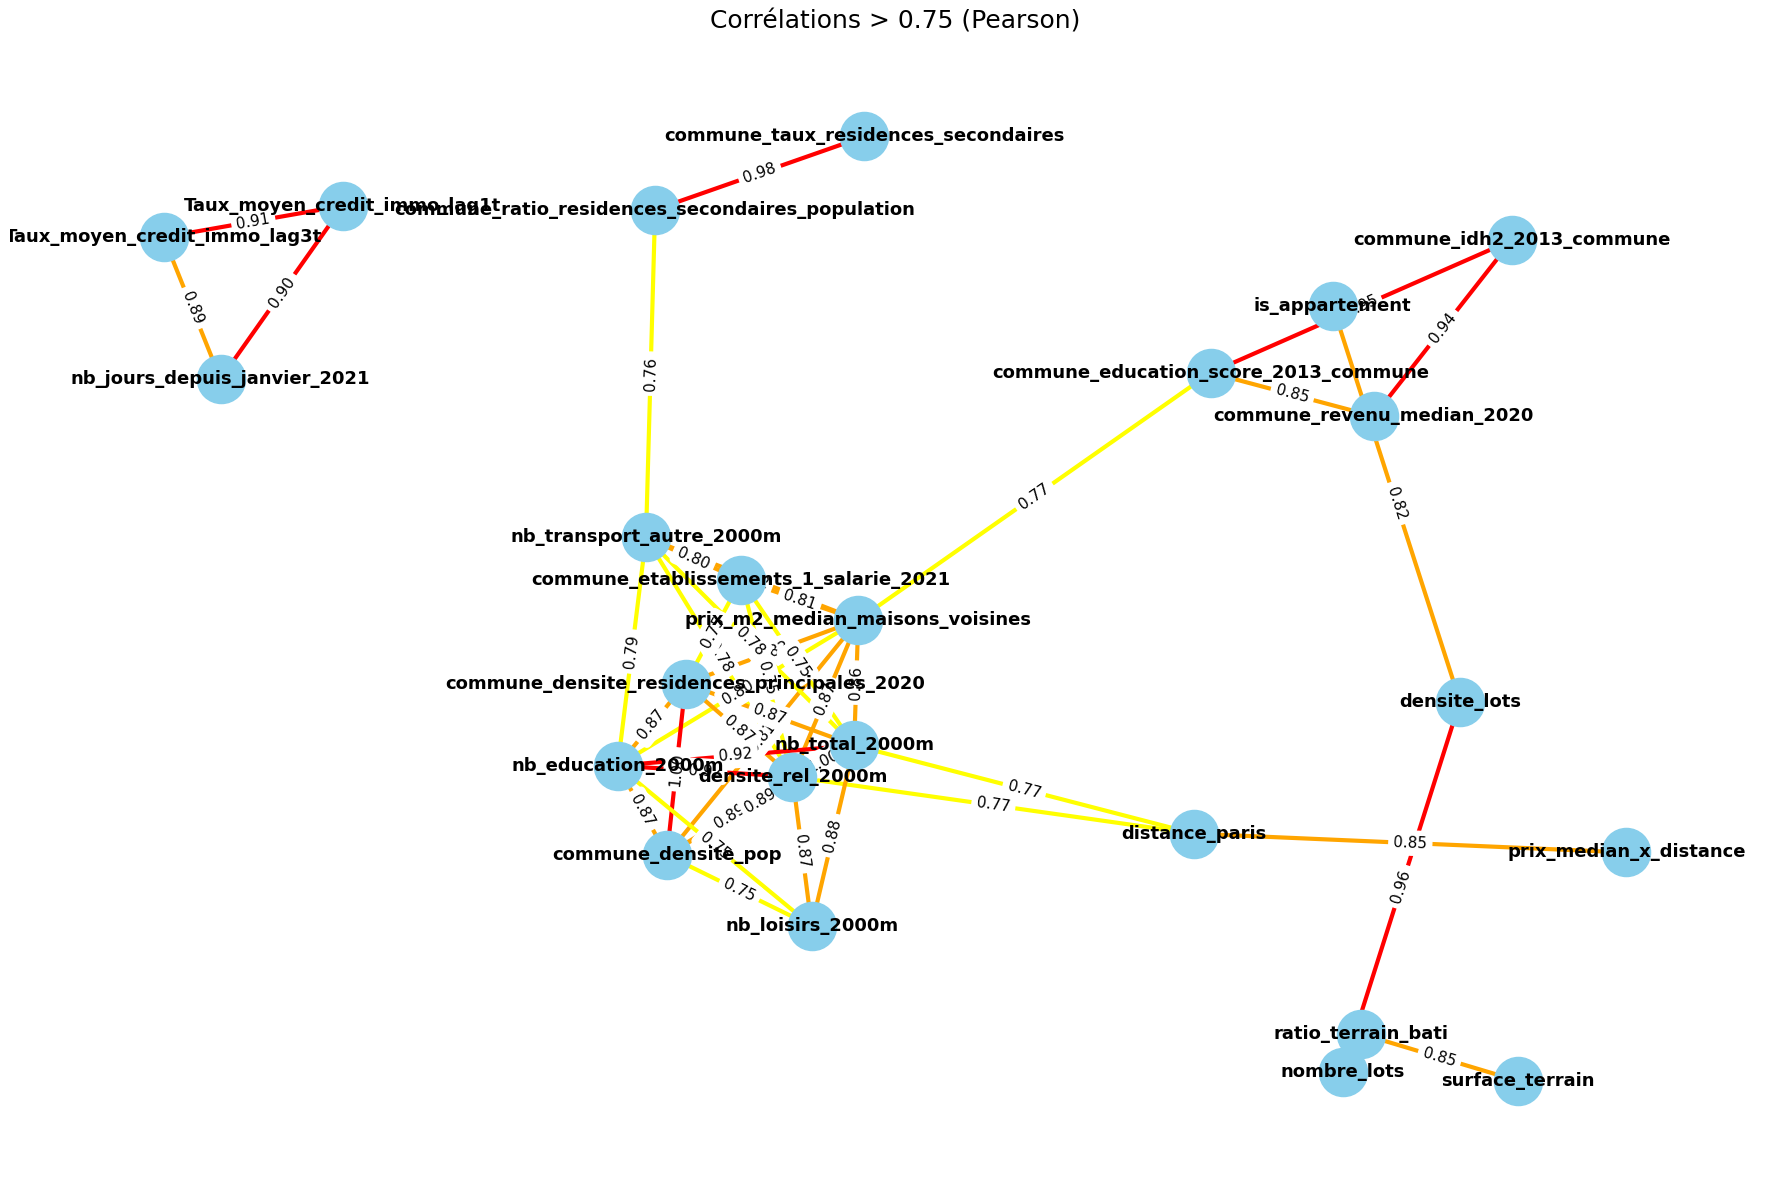

In [13]:
plot_strong_correlations(df_train_with_selected_features.drop(columns="prix_m2"), threshold=0.75)

A partir de cette annalyse on va enlever quelques variables, on garde à chaque fois la variable qui a la plus grande valeur de shapley:

In [14]:
correlated_features_to_drop = ["surface_terrain",
                               "densite_lots", 
                               "Taux_moyen_credit_immo_lag3t", 
                               "nb_jours_depuis_janvier_2021", # cette variable ne fait pas sens
                               "nb_education_2000m", 
                               "commune_idh2_2013_commune", 
                               "prix_median_x_distance",
                               "commune_taux_residences_secondaires",
                               "nb_total_2000m", 
                               "commune_densite_pop"
                               ]

df_train_with_selected_features = df_train_with_selected_features.drop(columns=correlated_features_to_drop, errors='ignore')
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,nb_transport_autre_2000m,densite_rel_2000m,is_appartement,nombre_lots,commune_part_commerce_tourisme,distance_paris,...,commune_ratio_residences_secondaires_population,commune_etablissements_1_salarie_2021,surface_par_piece,dist_transport_lourd,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,nb_loisirs_2000m,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,prix_m2
0,9782.608398,0.000000,160,0.902589,27,1.355828,1,1,0.848215,0.042164,...,0.095065,9368,26.666666,268.899414,0.0373,0.325563,290,0.193834,17,7750.000000
1,5606.589355,0.000000,52,0.451268,4,0.241548,1,1,0.643595,0.073735,...,0.013689,1738,13.000000,319.581665,0.0399,0.282208,235,0.900489,8,4500.000000
2,3152.272705,0.000000,101,0.636588,2,-1.289530,0,1,0.600000,0.288966,...,0.014819,56,20.200001,1018.376892,0.0329,0.811383,33,0.506923,2,2623.762451
3,10938.690430,0.000000,36,0.824937,31,2.088961,1,1,0.852084,0.021931,...,0.093602,6757,18.000000,272.015564,0.0106,0.370956,307,15.361810,17,12111.111328
4,5555.555664,1.843374,83,0.650801,1,0.010234,0,0,0.773960,0.127345,...,0.016016,430,16.600000,992.912659,0.0106,0.483656,228,15.361810,3,8192.771484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,3135.065430,0.000000,204,0.549603,0,0.113545,1,2,0.724356,0.112861,...,0.005919,1638,20.400000,519.641785,0.0284,0.344608,248,0.440900,10,2774.509766
507384,7936.507812,0.000000,92,0.702535,4,0.693273,1,2,0.761356,0.083150,...,0.026443,2124,23.000000,366.157837,0.0113,0.422412,226,-12.214629,14,7282.608887
507385,1771.571777,0.000000,76,0.234840,1,-0.880271,0,1,0.664062,0.462352,...,0.004408,539,19.000000,1181.921875,0.0113,0.423093,33,-12.214629,3,2763.157959
507386,5403.879395,0.000000,160,0.470862,4,1.436748,1,1,0.739228,0.138005,...,0.014755,1926,26.666666,279.064087,0.0105,0.283137,331,-0.105712,15,5000.000000


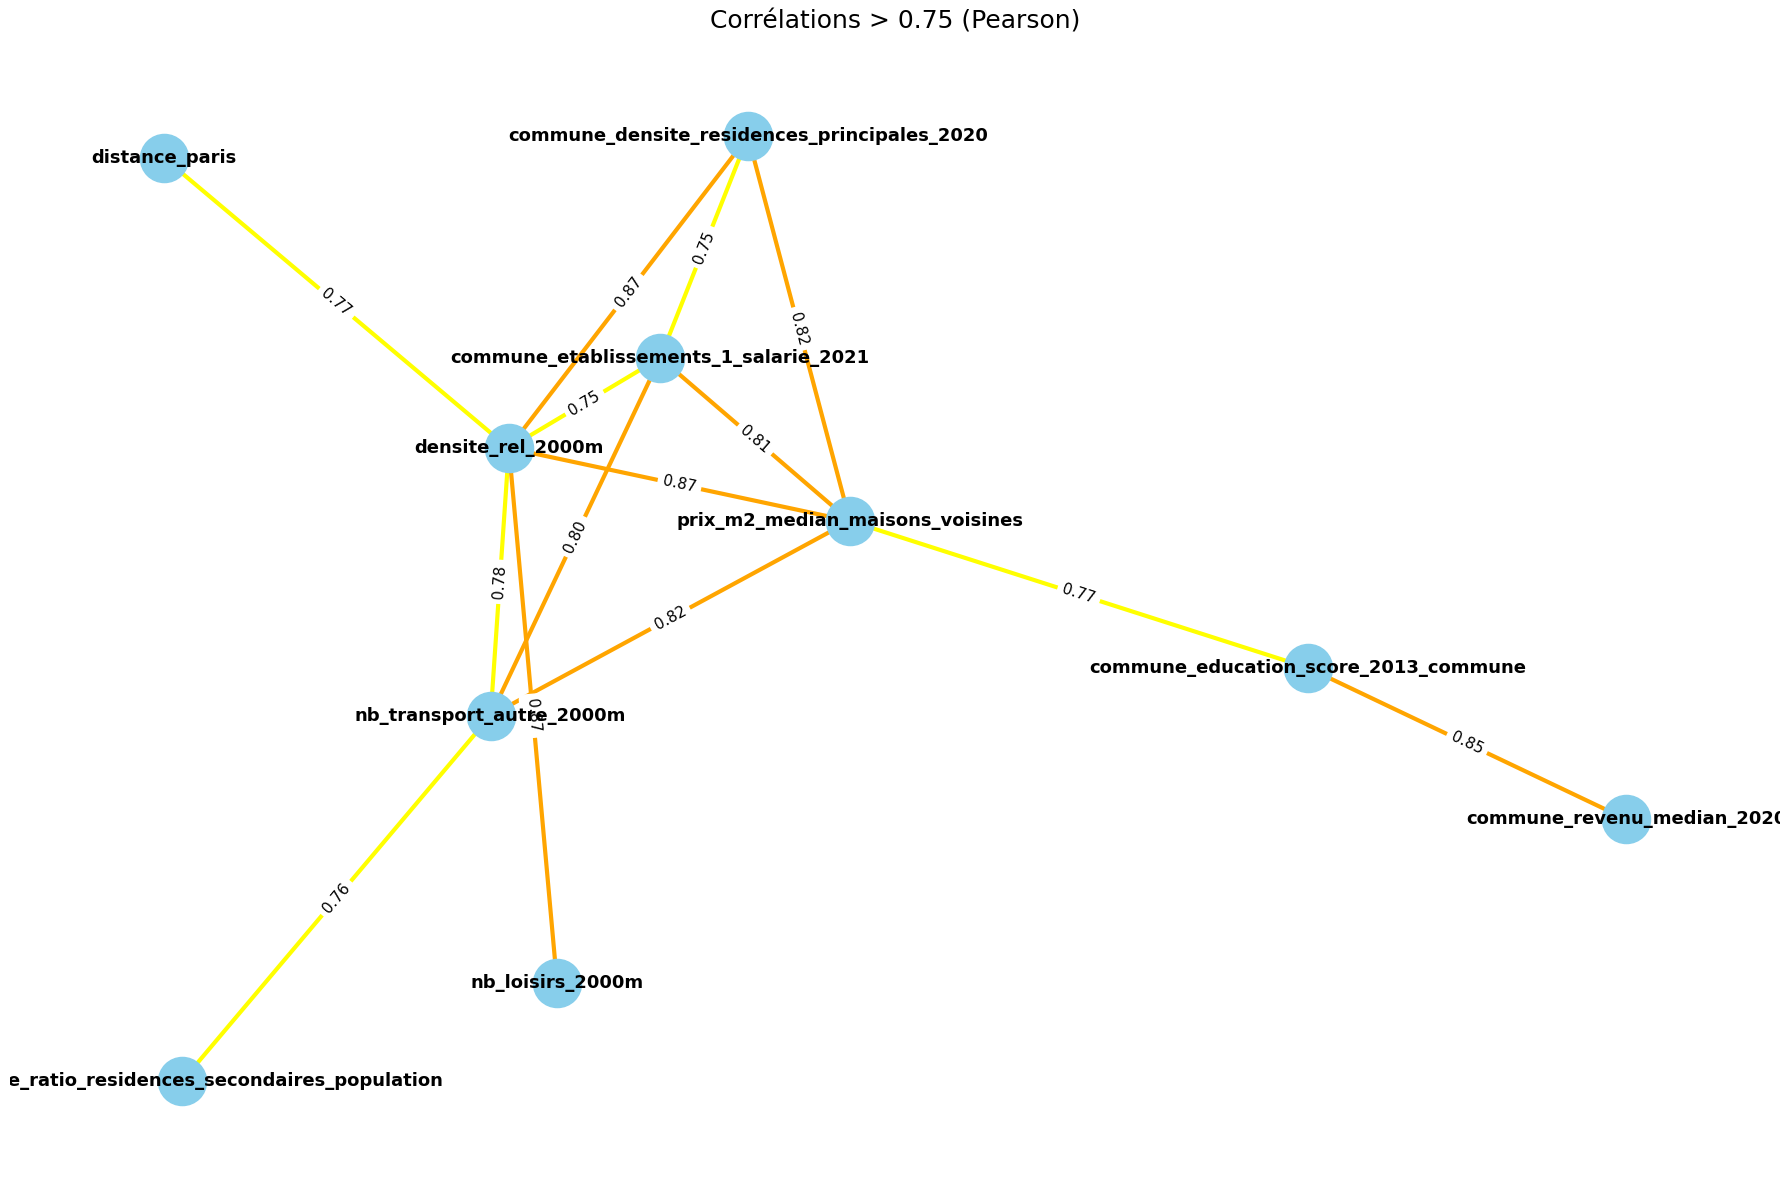

In [15]:
plot_strong_correlations(df_train_with_selected_features.drop(columns="prix_m2"), threshold=0.75)

Pour des modèles d'arbre ce n'est pas très grave pour la performance du modèle d'avoir des corrélations. Donc pour l'instant on garde le dataframe tel quel. Pour mieux comprendre les drivers du prix au mètre carré il faudra enlever le prix médian du metre carré des maisons voisines. 

On va rajouter le code departement :

In [13]:
df_train_with_selected_features = pd.concat([df_train_with_selected_features, df_code_departement], axis=1)
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,is_appartement,nb_transport_autre_2000m,densite_rel_2000m,nombre_lots,commune_part_commerce_tourisme,distance_paris,...,commune_ratio_residences_secondaires_population,surface_par_piece,dist_transport_lourd,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,nb_services_2000m,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,prix_m2,code_departement
0,9782.608398,0.000000,160,0.902589,1,27,1.355828,1,0.848215,0.042164,...,0.095065,26.666666,268.899414,290,0.0373,17,0.325563,0.193834,7750.000000,75
1,5606.589355,0.000000,52,0.451268,1,4,0.241548,1,0.643595,0.073735,...,0.013689,13.000000,319.581665,235,0.0399,8,0.282208,0.900489,4500.000000,93
2,3152.272705,0.000000,101,0.636588,0,2,-1.289530,1,0.600000,0.288966,...,0.014819,20.200001,1018.376892,33,0.0329,2,0.811383,0.506923,2623.762451,95
3,10938.690430,0.000000,36,0.824937,1,31,2.088961,1,0.852084,0.021931,...,0.093602,18.000000,272.015564,307,0.0106,17,0.370956,15.361810,12111.111328,75
4,5555.555664,1.843374,83,0.650801,0,1,0.010234,0,0.773960,0.127345,...,0.016016,16.600000,992.912659,228,0.0106,3,0.483656,15.361810,8192.771484,94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507383,3135.065430,0.000000,204,0.549603,1,0,0.113545,2,0.724356,0.112861,...,0.005919,20.400000,519.641785,248,0.0284,10,0.344608,0.440900,2774.509766,94
507384,7936.507812,0.000000,92,0.702535,1,4,0.693273,2,0.761356,0.083150,...,0.026443,23.000000,366.157837,226,0.0113,14,0.422412,-12.214629,7282.608887,92
507385,1771.571777,0.000000,76,0.234840,0,1,-0.880271,1,0.664062,0.462352,...,0.004408,19.000000,1181.921875,33,0.0113,3,0.423093,-12.214629,2763.157959,78
507386,5403.879395,0.000000,160,0.470862,1,4,1.436748,1,0.739228,0.138005,...,0.014755,26.666666,279.064087,331,0.0105,15,0.283137,-0.105712,5000.000000,92


Appliquer la selection à l'échantillon test et OOT :

In [14]:
test_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_test_cleaned.parquet")
test_df = test_df[selected_features + ["prix_m2", "code_departement"]]
test_df = test_df.drop(columns=correlated_features_to_drop, errors='ignore')
test_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,is_appartement,nb_transport_autre_2000m,densite_rel_2000m,nombre_lots,commune_part_commerce_tourisme,distance_paris,...,commune_ratio_residences_secondaires_population,surface_par_piece,dist_transport_lourd,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,nb_services_2000m,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,prix_m2,code_departement
0,7319.250977,0.000000,46,0.786667,1,5,1.363134,1,0.823801,0.059051,...,0.037000,23.000000,775.308411,441,0.0359,8,0.398941,0.451942,7147.826172,92
1,7331.214844,0.000000,210,0.832653,1,4,1.300839,1,0.837838,0.121252,...,0.081091,26.250000,256.409119,356,0.0140,15,0.428526,2.991206,7980.952148,92
2,11411.458008,0.000000,302,0.937021,1,46,1.558150,2,0.904373,0.036368,...,0.257066,37.750000,210.827072,180,0.0420,62,0.388839,0.075596,12317.880859,75
3,4528.928711,14.385965,57,0.586714,0,0,-0.635809,0,0.483516,0.149511,...,0.006706,19.000000,2193.941650,77,0.0178,3,0.654517,0.559991,8719.297852,95
4,2990.362305,0.000000,119,0.649757,0,2,-0.999867,1,0.674528,0.319220,...,0.007979,29.750000,108.422150,54,0.0105,1,0.682505,0.399707,2815.125977,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126843,3795.454590,1.735294,34,0.685132,0,1,-0.590734,0,0.701299,0.301805,...,0.008432,17.000000,658.067627,161,0.0105,5,0.649225,0.399707,4289.706055,91
126844,10100.000000,0.000000,44,0.865192,1,6,0.427209,1,0.804709,0.077590,...,0.036750,22.000000,29.374443,291,0.0178,7,0.478174,0.559991,10000.000000,94
126845,3167.094727,0.000000,94,0.469415,0,1,-1.289505,1,0.683168,0.381271,...,0.109685,18.799999,533.554138,47,0.0140,4,0.697908,2.991206,2340.425537,91
126846,5956.410156,0.000000,80,0.410136,1,5,0.903930,1,0.703074,0.071087,...,0.007103,20.000000,405.890564,275,0.0113,10,0.322951,-12.214629,4950.000000,93


In [15]:
oos_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_cleaned.parquet")
oos_df = oos_df[selected_features + ["prix_m2", "code_departement"]]
oos_df = oos_df.drop(columns=correlated_features_to_drop, errors='ignore')
oos_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,is_appartement,nb_transport_autre_2000m,densite_rel_2000m,nombre_lots,commune_part_commerce_tourisme,distance_paris,...,commune_ratio_residences_secondaires_population,surface_par_piece,dist_transport_lourd,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,nb_services_2000m,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,prix_m2,code_departement
0,4005.208252,0.000000,144,0.400966,1,2,0.003226,1,0.635346,0.074237,...,0.010006,24.000000,134.432617,255,0.0338,8,0.372387,0.144057,3097.222168,94
1,3682.135010,0.000000,156,0.610739,1,0,-0.832668,2,0.823000,0.176076,...,0.036247,19.500000,135.523117,72,0.0338,7,0.409828,0.144057,3551.281982,78
2,5482.353027,0.000000,30,0.889821,1,0,-0.042039,1,0.810565,0.104779,...,0.026782,15.000000,145.372406,174,0.0338,2,0.477340,0.144057,8000.000000,92
3,8277.418945,0.000000,124,0.835437,1,5,0.742554,1,0.834500,0.092758,...,0.054721,20.666666,622.195190,314,0.0338,6,0.422396,0.144057,7658.467773,92
4,2683.333252,0.000000,204,0.389963,1,1,-0.651608,1,0.659074,0.289832,...,0.004541,20.400000,1174.676025,127,0.0338,8,0.391079,0.144057,1980.392212,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47763,3621.912109,3.026316,76,0.523603,0,0,-1.089169,0,0.633484,0.297009,...,0.005232,19.000000,2226.469971,94,0.0316,2,0.649097,0.191300,3723.684326,77
47764,3579.545410,0.000000,184,0.473365,1,0,-0.129552,1,0.619617,0.203737,...,0.009441,23.000000,1345.507935,213,0.0316,6,0.650443,0.191300,1569.934814,91
47765,4420.212891,0.000000,120,0.682606,1,2,0.208427,1,0.755556,0.245933,...,0.044261,20.000000,1653.855713,326,0.0316,3,0.453915,0.191300,5000.000000,78
47766,4289.473633,3.674797,123,0.639937,0,1,-1.055975,0,0.637681,0.346691,...,0.004543,20.500000,1396.173706,64,0.0316,2,0.730947,0.191300,3869.918701,78


Export de la base :

In [16]:
df_train_with_selected_features.to_parquet(r"data/processed/selected_features/idf_vf_train_selected_features.parquet", index=False)
test_df.to_parquet(r"data/processed/selected_features/idf_vf_test_selected_features.parquet", index=False)
oos_df.to_parquet(r"data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet", index=False)